In [2]:
import os
import pandas as pd
import numpy as np
import stylia as st
from stylia import NamedColors
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

datapath = "../data"
figurepath = "../figures"

In [7]:
def plot_yhat(ax,df, name):
    y_hat = np.array(df['y_pred'].tolist())
    y_true = np.array(df['activity'].tolist())
    y_hats_1 = y_hat[y_true == 1]
    y_hats_0 = y_hat[y_true == 0]
    np.random.shuffle(y_hats_0)
    np.random.shuffle(y_hats_1)
    if len(y_hats_1)>100:
        y_hats_1[:100]
    if len(y_hats_0)>100:
        y_hats_0[:100]
    for y in zip(y_hats_0):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().gray
        ax.scatter([0 + jitter], [y], color=color, alpha=0.5)
    for y in zip(y_hats_1):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().red
        ax.scatter([1 + jitter], [y], color=color, alpha=0.5)
    ax.set_xticks([0,1])
    ax.set_xticklabels(["Neg", "Pos"])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(name)

def plot_roc_curve(ax, df, name):
    y_hat = np.array(df['y_pred'].tolist())
    y_true = np.array(df['activity'].tolist())
    fpr, tpr, _ = roc_curve(y_true, y_hat)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, color="#50285a",
            label=f"AUC = {roc_auc:.2f}")
    ax.set_title(f"ROC Curve {name}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(loc="lower right", fontsize=8)

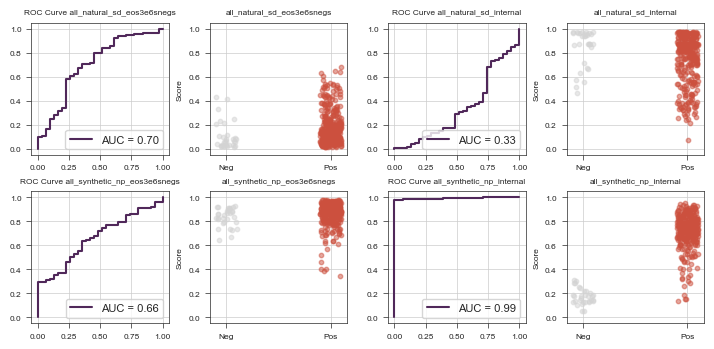

In [14]:
datasets = ["all_natural_sd_eos3e6snegs", "all_natural_sd_internal", "all_synthetic_np_eos3e6snegs", "all_synthetic_np_internal"]

fig, axs = st.create_figure(2,4)
for d in datasets:
    df = pd.read_csv(os.path.join(datapath, "lq_predictions", f"{d}.csv"))
    ax = axs.next()
    plot_roc_curve(ax, df, d)
    ax = axs.next()
    plot_yhat(ax, df, d)
plt.tight_layout()
